<a href="https://colab.research.google.com/github/jrapakko/cse11b/blob/main/Pandas_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Notebook is adapted from the one provided by the book, *Hands-on Machine Learning with Scikit-Learn, Keras and TensorFlow (3rd edition)* by Aurélien Geron.

## Introduction

This Notebook is intended to give you some exposure to the Pandas library, which you may find helpful in your cours projects. It is only a small sample of the library's functionality, but provides a good starting point.

As you read through the Notebook, you are encouraged to change the values in cells to see how the output changes. In doing so, you will gain a better understanding of what these methods do.

If you get an unexpected error, be sure to click "Run all" at the top (or, at least, "Run before" from the Runtime menu) to ensure all cells preceding the current cell have re-run.

Please reach out to me if you have any questions or difficulty running cells in the Notebook.

**You do not need to submit this Notebook.** It is for practice only.

## Importing Pandas
Use the following line whenever importing Pandas in a module.

As a convention (and convenience), the module is almost always aliased as `pd`.

In [1]:
import pandas as pd

## Data Structures
The Pandas library is powered by two main data structures, each of which has a collection of methods associated with it.

  - Series: A 1-dimensional array, often used to represent a single row or column of data.
  - DataFrame: A 2-dimensional matrix, with both rows and columns.

## The Series Data Structure

### Creating a Series from a List
To instantiate a Series object from a list, simply pass the list as an argument to `pd.Series`.

The output of this cell shows the values on the right, along with their indices (starting from zero) on the left. At the bottom, we see that the data type of this Series is 64-bit integer.

In [38]:
s = pd.Series([2, -1, 3, 5])

### Indices
Each value in a Series has a unique index, which starts at zero.

You can also choose to label the values with strings, which can be useful when the values are not in any particular order.

In [39]:
s2 = pd.Series([68, 83, 112, 68], index=["alice", "bob", "charles", "darwin"])
s2

,0
alice,68
bob,83
charles,112
darwin,68


To get a single value from a Series with string labels, you can use square brackets with the label's name as a string (just like how you would access values in a Python dictionary).

In [40]:
s2["bob"]

np.int64(83)

To make it clear when you are accessing by label or by integer location, it is recommended to always use the `loc` attribute when accessing by label, and the `iloc` attribute when accessing by integer location:

In [32]:
s2.loc["bob"]

np.int64(83)

In [33]:
s2.iloc[1]

np.int64(83)

Slicing a `Series` also slices the index labels:

In [34]:
s2.iloc[1:3]

,0
bob,83
charles,112


### Creating a Series from a Dictionary
As with lists, passing a Python dictionary to `pd.Series` also creates a new Series. This method has the added benefit of allowing you to specify labels with the dictionary keys.

In [35]:
weights = {"alice": 68, "bob": 83, "colin": 86, "darwin": 68}
s3 = pd.Series(weights)
s3

,0
alice,68
bob,83
colin,86
darwin,68


### Create a Series from a Scalar Value
If you want to initialize a Series such that all values are the same, just pass that value to `pd.Series`. This method can be useful when initializing a Series with zeros.

In [36]:
pd.Series(0, ["alice", "bob", "colin", "darwin"])

,0
alice,0
bob,0
colin,0
darwin,0


### Plotting a Series
One of the amazing aspects of the Pandas library is the ease with which data can be visualized. (For those curious: Pandas uses the package `matplotlib` to generate these visualizations.)

<Axes: >

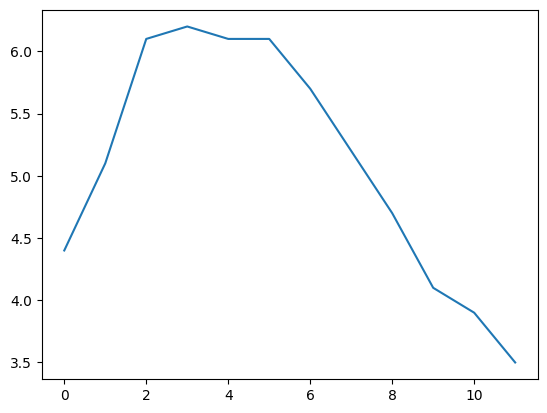

In [37]:
temperatures = [4.4, 5.1, 6.1, 6.2, 6.1, 6.1, 5.7, 5.2, 4.7, 4.1, 3.9, 3.5]
s7 = pd.Series(temperatures, name="Temperature")
s7.plot()

Pandas has many visualization options. For more examples, see the [chart visualization guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html).

## The DataFrame Object
As mentioned above, DataFrames are 2D matrices with rows and columns. Each column usually has a name (which must be unique). Rows can also have names but are usually numerical indices.

### Creating a DataFrame
As a Series is a 1D array, you can think of it as a single row or column. Since a DataFrame is composed of multiple rows and columns, you can create a DataFrame from a collection of Series objects.

In [41]:
people_dict = {
    "weight": pd.Series([68, 83, 112], index=["alice", "bob", "charles"]),
    "birthyear": pd.Series([1984, 1985, 1992], index=["bob", "alice", "charles"], name="year"),
    "children": pd.Series([0, 3], index=["charles", "bob"]),
    "hobby": pd.Series(["Biking", "Dancing"], index=["alice", "bob"]),
}
people = pd.DataFrame(people_dict)
people

,weight,birthyear,children,hobby
alice,68,1985,NaN,Biking
bob,83,1984,3.0,Dancing
charles,112,1992,0.0,NaN


Note that since there was no `children` value for `"alice"`, it defaults to NaN (Not a Number) rather than zero.


You can access entire columns the same way that you accessed individual values with a Series.

In [42]:
people["birthyear"]

,birthyear
alice,1985
bob,1984
charles,1992


Multiple columns can be accessed at once in this way, which results in a DataFrame instead of a Series.

In [43]:
people[["birthyear", "hobby"]]

,birthyear,hobby
alice,1985,Biking
bob,1984,Dancing
charles,1992,NaN


DataFrames can be created with dictionaries, where each key is the name of a column, and each value is a list (for number-indexed DataFrames) or another dictionary (for label-indexed DataFrames).

In [44]:
people = pd.DataFrame({
    "birthyear": {"alice": 1985, "bob": 1984, "charles": 1992},
    "hobby": {"alice": "Biking", "bob": "Dancing"},
    "weight": {"alice": 68, "bob": 83, "charles": 112},
    "children": {"bob": 3, "charles": 0}
})
people

,birthyear,hobby,weight,children
alice,1985,Biking,68,NaN
bob,1984,Dancing,83,3.0
charles,1992,NaN,112,0.0


### Transposing
You can transpose - that is, swap rows and columns - easily with the `T` attribute. Doing so does not modify the original DataFrame.

In [45]:
people.T

,alice,bob,charles
birthyear,1985,1984,1992
hobby,Biking,Dancing,NaN
weight,68,83,112
children,NaN,3.0,0.0


### Accessing Rows


Rows can be accessed by label names (when the DataFrame is label-indexed).

In [46]:
people.loc["charles"]

,charles
birthyear,1992
hobby,NaN
weight,112
children,0.0


Rows can also be accessed by position.
Note the difference between `.loc` and `.iloc`.

In [47]:
people.iloc[2]

,charles
birthyear,1992
hobby,NaN
weight,112
children,0.0


Similarly, DataFrames can be sliced like Python lists and strings using `.iloc`.

In [48]:
people.iloc[1:3]

,birthyear,hobby,weight,children
bob,1984,Dancing,83,3.0
charles,1992,NaN,112,0.0


Let's look at what happens when we use a Series as part of a Boolean expression.

In [49]:
people["birthyear"] < 1990

,birthyear
alice,True
bob,True
charles,False


As we can see above, we get a Series of Boolean values that indicate which values satisfied that expression.

When applied to a DataFrame, a sequence of Boolean values (like the above) can be used as a "mask", which results in only the rows for which the corresponding position in the mask was True.

In the example below, only rows for which `birthyear` is "less than 1990" are selected.

In [50]:
people[people["birthyear"] < 1990]

,birthyear,hobby,weight,children
alice,1985,Biking,68,NaN
bob,1984,Dancing,83,3.0


### Adding Columns

To add a column to a DataFrame, simply index on it with a column name it does not yet have. The assigned column must be of appropriate length.

In [51]:
people["age"] = 2025 - people["birthyear"]  # Adds "age" column
people["over 30"] = people["age"] > 30      # Adds "over 30" column
people

,birthyear,hobby,weight,children,age,over 30
alice,1985,Biking,68,NaN,40,True
bob,1984,Dancing,83,3.0,41,True
charles,1992,NaN,112,0.0,33,True


If some labels are missing, NaN is used for that row. If extra labels are provided, they are ignored.

In [52]:
people["pets"] = pd.Series({"bob": 0, "charles": 5, "eugene": 1})  # alice is missing, eugene is ignored
people

,birthyear,hobby,weight,children,age,over 30,pets
alice,1985,Biking,68,NaN,40,True,NaN
bob,1984,Dancing,83,3.0,41,True,0.0
charles,1992,NaN,112,0.0,33,True,5.0


Use `insert` to add a column at a location other than the very end.

In [53]:
people.insert(1, "height", [172, 181, 185])
people

,birthyear,height,hobby,weight,children,age,over 30,pets
alice,1985,172,Biking,68,NaN,40,True,NaN
bob,1984,181,Dancing,83,3.0,41,True,0.0
charles,1992,185,NaN,112,0.0,33,True,5.0


## Querying DataFrames
Similar to a database query, you can pass a string to `query` with conditional and Boolean operators to get only select rows.

In [54]:
people.query("age > 30 and pets == 0")

,birthyear,height,hobby,weight,children,age,over 30,pets
bob,1984,181,Dancing,83,3.0,41,True,0.0


The DataFrame can be sorted by its labeled index. As with most Pandas functions, a copy is returned but the original DataFrame remains unchanged.

In [55]:
people.sort_index(ascending=False)

,birthyear,height,hobby,weight,children,age,over 30,pets
charles,1992,185,NaN,112,0.0,33,True,5.0
bob,1984,181,Dancing,83,3.0,41,True,0.0
alice,1985,172,Biking,68,NaN,40,True,NaN


It can also be sorted by any column. Use `inplace` to modify the DataFrame object rather than having `sort_values` return a new DataFrame object.

The `inplace` keyword argument can be used for many other Series and DataFrame functions as well.

In [56]:
people.sort_values(by="age", inplace=True)
people

,birthyear,height,hobby,weight,children,age,over 30,pets
charles,1992,185,NaN,112,0.0,33,True,5.0
alice,1985,172,Biking,68,NaN,40,True,NaN
bob,1984,181,Dancing,83,3.0,41,True,0.0


## Plotting DataFrames
Pandas makes it easy to create charts from DataFrames, and there are many, many options.

A line chart is shown below, with the x-axis as the height and the y-axis as the weight of each person in the DataFrame.

<Axes: xlabel='height'>

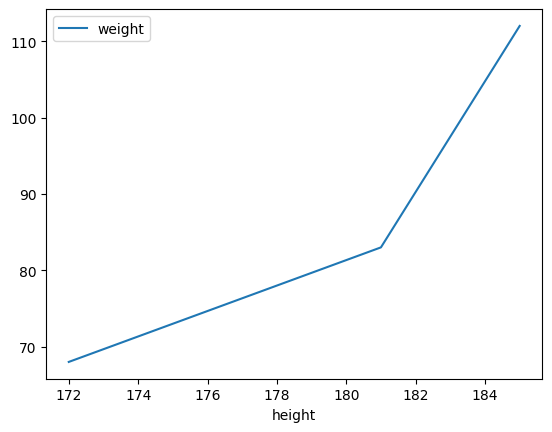

In [57]:
people.sort_values(by="weight", inplace=True)
people.plot(kind="line", x="height", y="weight")

Here's a scatter plot with the same axes. The `s` keyword argument allows you to control the size of each point; here, each point is assigned the size value corresponding to that row's age number.

<Axes: xlabel='height', ylabel='weight'>

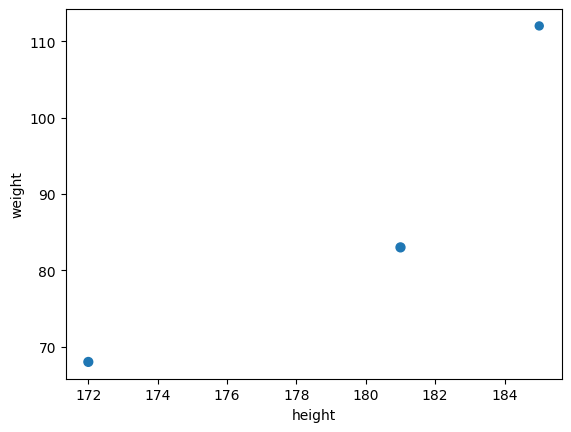

In [58]:
people.plot(kind="scatter", x="height", y="weight", s="age")

## Additional Practice
Check out the [author's version of the Notebook](https://colab.research.google.com/github/ageron/handson-ml3/blob/main/tools_pandas.ipynb), which has many more sections. (This Notebook was edited from the author's version to be more concise and focus on core features.)

You can also look at [10 minutes to Pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html) in the official documentation.